# Conditional Transformer-Based Generation of 2D Platformer Level Segments

**Student:** Robert Mayfield  
**Dataset:** Video Game Level Corpus (VGLC): Super Mario Bros tile based level files  
**Model:** Conditional decoder-only Transformer with difficulty control tokens

## Project Overview

In [1]:
import json
import pickle
import random
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from src.data_processing import chunk_level, load_level_corpus
from src.feature_engineering import (
    COLLECTIBLE_TILES,
    ENEMY_TILES,
    HAZARD_TILES,
    SOLID_TILES,
    compute_collectible_density,
    compute_enemy_density,
    compute_hazard_density,
    compute_longest_gap,
    compute_solid_ratio,
    engineer_features,
)
from src.labeling import assign_difficulty_label, compute_difficulty_score
from src.model import LevelTransformer, count_parameters
from src.tokenizer import (
    CHAR_TO_ID,
    CONTROL_TOKEN_NAMES,
    CONTROL_TOKENS,
    ID_TO_CHAR,
    SEQ_LEN,
    TILE_CHARS,
    VOCAB_SIZE,
    LevelChunkDataset,
    decode_sequence,
    tokenize_chunk,
)

In [2]:
%matplotlib inline

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Dataset Loading and Inspection

In [4]:
DATA_DIR = Path("../data/raw")
levels, tile_spec = load_level_corpus(DATA_DIR)
print(f"Loaded {len(levels)} levels")
print(f"Tile vocabulary: {len(tile_spec)} tile types")

Loaded 15 levels
Tile vocabulary: 13 tile types


In [5]:
def inspect_level_corpus(levels: list[dict]) -> pd.DataFrame:
    """Return a DataFrame of per-level structural statistics.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    pd.DataFrame
        One row per level: name, rows, cols, total_tiles.
    """
    records = []
    for lvl in levels:
        row_count = len(lvl["rows"])
        col_count = max(len(r) for r in lvl["rows"]) if lvl["rows"] else 0
        records.append({
            "name": lvl["name"],
            "rows": row_count,
            "cols": col_count,
            "total_tiles": row_count * col_count,
        })
    return pd.DataFrame(records)


corpus_stats = inspect_level_corpus(levels)
print(corpus_stats.to_string(index=False))
print(f"\nRow height consistent: {corpus_stats['rows'].nunique() == 1} ({corpus_stats['rows'].iloc[0]} rows)")
print(f"Width range: {corpus_stats['cols'].min()} to {corpus_stats['cols'].max()} columns")
print(f"Total tiles in corpus: {corpus_stats['total_tiles'].sum():,}")

     name  rows  cols  total_tiles
mario-1-1    14   202         2828
mario-1-2    14   158         2212
mario-1-3    14   150         2100
mario-2-1    14   197         2758
mario-3-1    14   197         2758
mario-3-3    14   149         2086
mario-4-1    14   222         3108
mario-4-2    14   187         2618
mario-5-1    14   198         2772
mario-5-3    14   150         2100
mario-6-1    14   184         2576
mario-6-2    14   215         3010
mario-6-3    14   165         2310
mario-7-1    14   176         2464
mario-8-1    14   373         5222

Row height consistent: True (14 rows)
Width range: 149 to 373 columns
Total tiles in corpus: 40,922


In [6]:
def display_level(level: dict, max_cols: int = 80) -> None:
    """Print a level tile grid to stdout, truncated to max_cols width.

    Parameters
    ----------
    level : dict
        Level dict with keys 'name' and 'rows'.
    max_cols : int
        Maximum columns to display. Default 80.
    """
    n_rows = len(level["rows"])
    n_cols = len(level["rows"][0]) if level["rows"] else 0
    print(f"  {level['name']}  ({n_rows} rows x {n_cols} cols)")
    print("  " + "-" * min(max_cols, n_cols))
    for row in level["rows"]:
        print("  " + row[:max_cols])


print("Sample levels (first 80 columns):\n")
display_level(levels[0])
print()
display_level(levels[7])

Sample levels (first 80 columns):

  mario-1-1  (14 rows x 202 cols)
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  ----------------------Q---------------------------------------------------------
  --------------------------------------------------------------------------------
  -------------------------------------------------------------------------------E
  ----------------------------------------------------------------S---------------
  ----------------Q---S?SQS---------------------<>---------<>------------------S?S
  ----------------

In [7]:
def count_tile_frequencies(levels: list[dict]) -> Counter:
    """Count each tile character across the full corpus.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    Counter
        Tile character to total count across all levels.
    """
    counts = Counter()
    for lvl in levels:
        for row in lvl["rows"]:
            counts.update(row)
    return counts


tile_counts = count_tile_frequencies(levels)
total_tiles = sum(tile_counts.values())

print(f"{'Tile':<6} {'Count':>8} {'Pct':>8}  Properties")
print("-" * 55)
for ch, count in tile_counts.most_common():
    props = ", ".join(tile_spec.get(ch, ["unknown"]))
    print(f"  {repr(ch):<4} {count:>8,} {count / total_tiles * 100:>7.2f}%  {props}")

Tile      Count      Pct  Properties
-------------------------------------------------------
  '-'    35,277   86.21%  passable, empty
  'X'     3,600    8.80%  solid, ground
  'S'       932    2.28%  solid, breakable
  'E'       275    0.67%  enemy, damaging, hazard, moving
  '['       186    0.45%  solid, left pipe, pipe
  ']'       186    0.45%  solid, right pipe, pipe
  'o'       166    0.41%  coin, collectable, passable
  '<'        85    0.21%  solid, top-left pipe, pipe
  '>'        85    0.21%  solid, top-right pipe, pipe
  'Q'        70    0.17%  solid, question block, empty question block
  '?'        31    0.08%  solid, question block, full question block
  'B'        16    0.04%  Cannon top, cannon, solid, hazard
  'b'        13    0.03%  Cannon bottom, cannon, solid


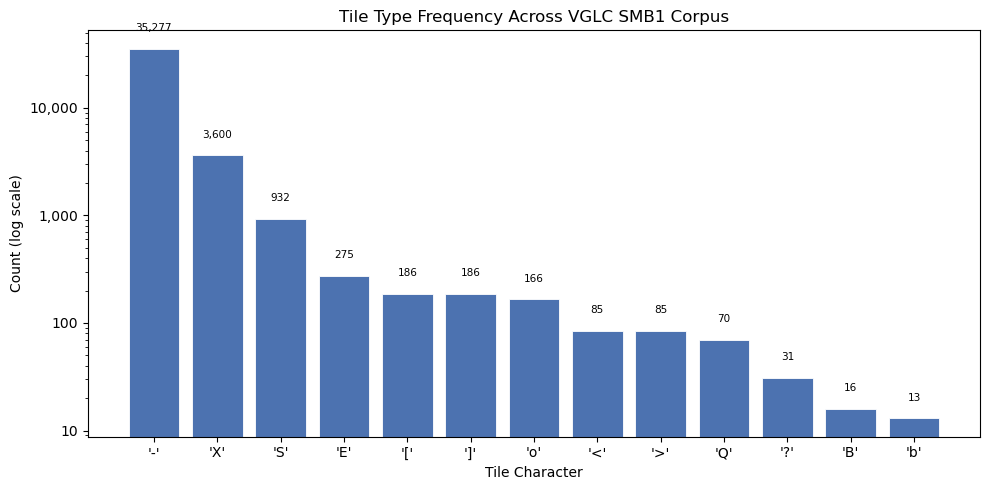

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

tile_labels = [repr(ch) for ch, _ in tile_counts.most_common()]
tile_values = [count for _, count in tile_counts.most_common()]

bars = ax.bar(tile_labels, tile_values, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("Tile Type Frequency Across VGLC SMB1 Corpus")
ax.set_xlabel("Tile Character")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, val in zip(bars, tile_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val * 1.4,
        f"{val:,}", ha="center", va="bottom", fontsize=7.5,
    )

plt.tight_layout()
plt.savefig("../outputs/figures/tile_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=== ROW LENGTH CONSISTENCY ===")
for lvl in levels:
    lengths = [len(r) for r in lvl["rows"]]
    min_l, max_l = min(lengths), max(lengths)
    flag = "" if min_l == max_l else " <-- RAGGED"
    print(f"{lvl['name']}: min={min_l}, max={max_l}, consistent={min_l == max_l}{flag}")

print()
print("=== INVALID CHARACTERS ===")
valid_chars = set(tile_spec.keys())
for lvl in levels:
    chars = set(c for r in lvl["rows"] for c in r)
    invalid = chars - valid_chars
    status = f"invalid: {invalid}" if invalid else "clean"
    print(f"{lvl['name']}: {status}")

print()
print("=== EMPTY ROWS ===")
for lvl in levels:
    empty = [i for i, r in enumerate(lvl["rows"]) if len(r) == 0]
    status = f"empty at rows {empty}" if empty else "none"
    print(f"{lvl['name']}: {status}")


=== ROW LENGTH CONSISTENCY ===
mario-1-1: min=202, max=202, consistent=True
mario-1-2: min=158, max=158, consistent=True
mario-1-3: min=150, max=150, consistent=True
mario-2-1: min=197, max=197, consistent=True
mario-3-1: min=197, max=197, consistent=True
mario-3-3: min=149, max=149, consistent=True
mario-4-1: min=222, max=222, consistent=True
mario-4-2: min=187, max=187, consistent=True
mario-5-1: min=198, max=198, consistent=True
mario-5-3: min=150, max=150, consistent=True
mario-6-1: min=184, max=184, consistent=True
mario-6-2: min=215, max=215, consistent=True
mario-6-3: min=165, max=165, consistent=True
mario-7-1: min=176, max=176, consistent=True
mario-8-1: min=373, max=373, consistent=True

=== INVALID CHARACTERS ===
mario-1-1: clean
mario-1-2: clean
mario-1-3: clean
mario-2-1: clean
mario-3-1: clean
mario-3-3: clean
mario-4-1: clean
mario-4-2: clean
mario-5-1: clean
mario-5-3: clean
mario-6-1: clean
mario-6-2: clean
mario-6-3: clean
mario-7-1: clean
mario-8-1: clean

=== EMPTY 

The corpus contains 15 overworld platformer levels from Super Mario Bros, totaling 40,922 tiles. All levels share a consistent height of 14 rows, while widths range from 149 to 373 columns. The outlier is mario-8-1 at 373 columns, roughly twice the width of the average level, reflecting its role as the final world's extended gauntlet stage.

Tile distribution is heavily skewed toward the empty sky tile (`-`), which accounts for 86.21% of all tiles. Ground tiles (`X`) are second at 8.80%, followed by breakable blocks (`S`) at 2.28%. Interactive and hazard tiles such as enemies (`E`), pipes, coins, and question blocks together make up less than 3% of the corpus. The log scale on the chart is necessary to make the rarer tile types visible at all.

This extreme imbalance has a direct consequence for training: a model that predicts `-` for every token would achieve roughly 86% token level accuracy without learning any meaningful structure. Evaluation must therefore look beyond raw accuracy to structural validity, diversity, and difficulty alignment. The imbalance also means that rare tiles such as enemies and question blocks are underrepresented in training, which may limit the model's ability to place them correctly in generated output.

Data quality checks confirm the corpus is clean and ready for chunking. All rows within every level are uniform width with no ragged edges, all characters belong to the 13 tile vocabulary with no unexpected symbols, and no empty rows are present. No cleaning or imputation step is required before feature engineering.

## Level Feature Engineering

We split each level into fixed width chunks of 14 rows by 32 columns with a stride of 16 columns, then compute five structural features for each chunk: enemy density, hazard density, longest ground gap, solid tile ratio, and collectible density. These features drive the difficulty scoring in the next section.

In [10]:
print(f"Solid tiles:       {sorted(SOLID_TILES)}")
print(f"Hazard tiles:      {sorted(HAZARD_TILES)}")
print(f"Enemy tiles:       {sorted(ENEMY_TILES)}")
print(f"Collectible tiles: {sorted(COLLECTIBLE_TILES)}")

all_chunks = [chunk for lvl in levels for chunk in chunk_level(lvl)]
print(f"\nTotal chunks: {len(all_chunks)}")
print("Chunks per level:")
for lvl in levels:
    n = len(chunk_level(lvl))
    print(f"  {lvl['name']} ({len(lvl['rows'][0])} cols) -> {n} chunks")

Solid tiles:       ['<', '>', '?', 'B', 'Q', 'S', 'X', '[', ']', 'b']
Hazard tiles:      ['B', 'E']
Enemy tiles:       ['E']
Collectible tiles: ['o']

Total chunks: 161
Chunks per level:
  mario-1-1 (202 cols) -> 11 chunks
  mario-1-2 (158 cols) -> 8 chunks
  mario-1-3 (150 cols) -> 8 chunks
  mario-2-1 (197 cols) -> 11 chunks
  mario-3-1 (197 cols) -> 11 chunks
  mario-3-3 (149 cols) -> 8 chunks
  mario-4-1 (222 cols) -> 12 chunks
  mario-4-2 (187 cols) -> 10 chunks
  mario-5-1 (198 cols) -> 11 chunks
  mario-5-3 (150 cols) -> 8 chunks
  mario-6-1 (184 cols) -> 10 chunks
  mario-6-2 (215 cols) -> 12 chunks
  mario-6-3 (165 cols) -> 9 chunks
  mario-7-1 (176 cols) -> 10 chunks
  mario-8-1 (373 cols) -> 22 chunks


In [11]:
chunk_features = pd.DataFrame([engineer_features(c) for c in all_chunks])
print(f"chunk_features shape: {chunk_features.shape}")
print()
print(chunk_features.head(8).to_string(index=False))
print()
print("Feature summary:")
print(chunk_features.drop(columns=["level_name", "col_start"]).describe().round(4).to_string())

chunk_features shape: (161, 7)

level_name  col_start  enemy_density  hazard_density  longest_gap  solid_ratio  collectible_density
 mario-1-1          0       0.002232        0.002232            0     0.095982                  0.0
 mario-1-1         16       0.004464        0.004464            0     0.127232                  0.0
 mario-1-1         32       0.006696        0.006696            0     0.120536                  0.0
 mario-1-1         48       0.006696        0.006696            2     0.093750                  0.0
 mario-1-1         64       0.006696        0.006696            3     0.098214                  0.0
 mario-1-1         80       0.008929        0.008929            3     0.104911                  0.0
 mario-1-1         96       0.011161        0.011161            0     0.093750                  0.0
 mario-1-1        112       0.008929        0.008929            0     0.140625                  0.0

Feature summary:
       enemy_density  hazard_density  longest_gap 

Chunking produced 161 training samples across the 15 levels, ranging from 8 chunks for the shorter levels to 22 for mario-8-1. Each chunk is 14 rows by 32 columns, giving 448 tiles per sample.

Tile category derivation from the spec identified 10 solid tile types, 2 hazard types (enemies `E` and cannon tops `B`), 1 enemy type, and 1 collectible type. Hazard density and enemy density are nearly identical across all chunks because cannon tiles account for only 16 total tiles in the corpus, making `E` the dominant hazard by a wide margin.

The feature distributions reflect the sparse, structured nature of Mario level design. Enemy density averages 0.72% with a max of 2.23%, confirming that most chunks contain few or no enemies. Collectible density has a median of 0, meaning the majority of chunks contain no coins at all. Solid ratio spans from 3.8% to 52.5%, capturing the range from open sky sections to heavily platformed areas like those seen in mario-4-2.

Longest gap shows the most variance of any feature, with a standard deviation of 8.0 and a maximum of 32. A value of 32 means the entire bottom row of a chunk is empty, representing a continuous pit spanning the full chunk width. These pit chunks will be important markers for hard difficulty labeling. The 25th percentile is 0, confirming that most chunks have solid ground throughout.

## Difficulty Scoring and Labeling

We compute a heuristic difficulty score for each chunk using a weighted combination of enemy density, longest ground gap, and hazard density. Thresholds are set at the 33rd and 67th percentiles of the score distribution to ensure balanced class sizes across Easy, Medium, and Hard labels.

In [12]:
chunk_features["difficulty_score"] = chunk_features.apply(compute_difficulty_score, axis=1)
print("Difficulty score summary:")
print(chunk_features["difficulty_score"].describe().round(3).to_string())

Difficulty score summary:
count    161.000
mean      28.779
std       40.054
min        0.000
25%        1.094
50%       15.000
75%       30.469
max      160.000


In [13]:
EASY_THRESHOLD = chunk_features["difficulty_score"].quantile(1 / 3)
HARD_THRESHOLD = chunk_features["difficulty_score"].quantile(2 / 3)

chunk_features["difficulty_label"] = chunk_features["difficulty_score"].apply(
    lambda s: assign_difficulty_label(s, EASY_THRESHOLD, HARD_THRESHOLD)
)

print(f"Easy   < {EASY_THRESHOLD:.3f}")
print(f"Medium   {EASY_THRESHOLD:.3f} to {HARD_THRESHOLD:.3f}")
print(f"Hard   >= {HARD_THRESHOLD:.3f}")
print()
print("Class distribution:")
print(chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"]).to_string())

Easy   < 5.677
Medium   5.677 to 20.781
Hard   >= 20.781

Class distribution:
difficulty_label
Easy      54
Medium    52
Hard      55


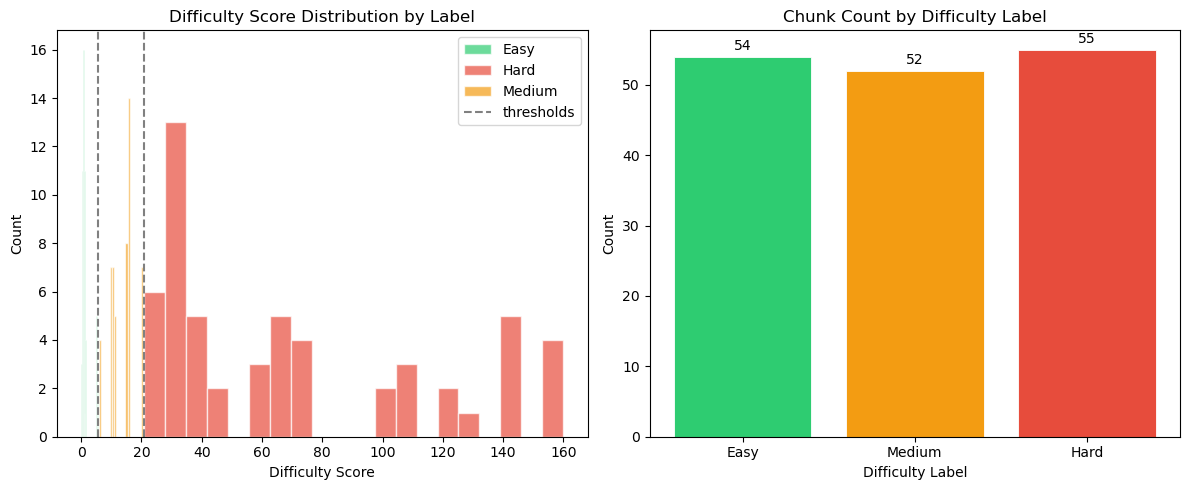

In [14]:
LABEL_COLORS = {"Easy": "#2ecc71", "Medium": "#f39c12", "Hard": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, grp in chunk_features.groupby("difficulty_label"):
    axes[0].hist(grp["difficulty_score"], bins=20, alpha=0.7,
                 label=label, color=LABEL_COLORS[label], edgecolor="white")
axes[0].axvline(EASY_THRESHOLD, color="gray", linestyle="--", linewidth=1.5, label="thresholds")
axes[0].axvline(HARD_THRESHOLD, color="gray", linestyle="--", linewidth=1.5)
axes[0].set_title("Difficulty Score Distribution by Label")
axes[0].set_xlabel("Difficulty Score")
axes[0].set_ylabel("Count")
axes[0].legend()

counts = chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"])
bars = axes[1].bar(counts.index, counts.values,
                   color=[LABEL_COLORS[l] for l in counts.index],
                   edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 str(val), ha="center", va="bottom", fontsize=10)
axes[1].set_title("Chunk Count by Difficulty Label")
axes[1].set_xlabel("Difficulty Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/figures/difficulty_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The raw difficulty score is heavily right skewed, with a mean of 28.8, a median of 15.0, and a standard deviation of 40.1. The majority of chunks score near zero, while a small number of outliers reach up to 160. The highest scoring chunks belong to mario-1-3, mario-3-3, mario-5-3, and mario-6-3, which contain the largest ground gaps in the corpus. The single chunk with a longest_gap of 32 belongs to mario-6-3 at column offset 48.

Percentile thresholds produced a near perfectly balanced class distribution: 54 Easy, 52 Medium, and 55 Hard chunks out of 161 total. The Easy boundary falls at a score of 5.68, capturing chunks with little to no gap and minimal enemies. The Hard boundary falls at 20.78, separating chunks with moderate gaps and enemy placement from those with extended pits or dense hazards.

The longest gap feature dominates the score by design. Pit navigation is the primary mechanical challenge in Super Mario Bros, so weighting it heavily reflects the actual source of difficulty in the training data. The density features (enemy and hazard) contribute a small secondary signal, distinguishing chunks that are structurally similar in terms of gaps but differ in enemy placement.

These labels are heuristic approximations. They are derived from structural features rather than player playtesting, completion rates, or observed player behavior. A chunk labeled Hard by this system may not feel hard to an experienced player, and a chunk labeled Easy may still be challenging to a new player. This limitation is addressed further in the Limitations section.

## Tokenization and Data Pipeline

We build a character-level vocabulary from the 13 tile types and 3 difficulty control tokens, then convert each labeled chunk into a fixed-length integer sequence with the control token prepended. A stratified train/val split preserves class balance across both sets, and a PyTorch Dataset and DataLoader prepare the sequences for autoregressive training.

In [15]:
print(f"Tile chars:      {TILE_CHARS}")
print(f"CHAR_TO_ID:      {CHAR_TO_ID}")
print(f"Control tokens:  {CONTROL_TOKENS}")
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sequence length: {SEQ_LEN}")

Tile chars:      ['-', '<', '>', '?', 'B', 'E', 'Q', 'S', 'X', '[', ']', 'b', 'o']
CHAR_TO_ID:      {'-': 0, '<': 1, '>': 2, '?': 3, 'B': 4, 'E': 5, 'Q': 6, 'S': 7, 'X': 8, '[': 9, ']': 10, 'b': 11, 'o': 12}
Control tokens:  {'Easy': 13, 'Medium': 14, 'Hard': 15}
Vocabulary size: 16
Sequence length: 449


In [16]:
labels    = chunk_features["difficulty_label"].tolist()
sequences = [tokenize_chunk(chunk, label) for chunk, label in zip(all_chunks, labels)]

print(f"Total sequences: {len(sequences)}")
print(f"Sequence length: {len(sequences[0])}  (expected {SEQ_LEN})")
print(f"\nSample sequence (first 20 tokens): {sequences[0][:20]}")
print(f"Control token decoded: {CONTROL_TOKEN_NAMES[sequences[0][0]]}")
print(f"First 5 tile tokens decoded: {[ID_TO_CHAR[t] for t in sequences[0][1:6]]}")

Total sequences: 161
Sequence length: 449  (expected 449)

Sample sequence (first 20 tokens): [13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Control token decoded: Easy
First 5 tile tokens decoded: ['-', '-', '-', '-', '-']


In [17]:
train_seqs, val_seqs, train_labels, val_labels = train_test_split(
    sequences, labels, test_size=0.2, random_state=SEED, stratify=labels
)
print(f"Train: {len(train_seqs)} sequences")
print(f"Val:   {len(val_seqs)} sequences")
print(f"\nTrain label distribution: {{k: int(v) for k, v in pd.Series(train_labels).value_counts().reindex(['Easy','Medium','Hard']).items()}}")
print(f"Val label distribution:   {{k: int(v) for k, v in pd.Series(val_labels).value_counts().reindex(['Easy','Medium','Hard']).items()}}")

BATCH_SIZE = 32

train_dataset = LevelChunkDataset(train_seqs)
val_dataset   = LevelChunkDataset(val_seqs)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatch size:     {BATCH_SIZE}")
print(f"Train batches:  {len(train_loader)}")
print(f"Val batches:    {len(val_loader)}")

x_batch, y_batch = next(iter(train_loader))
print(f"\nInput batch shape:  {tuple(x_batch.shape)}  (batch x seq_len-1)")
print(f"Target batch shape: {tuple(y_batch.shape)}")

Train: 128 sequences
Val:   33 sequences

Train label distribution: {k: int(v) for k, v in pd.Series(train_labels).value_counts().reindex(['Easy','Medium','Hard']).items()}
Val label distribution:   {k: int(v) for k, v in pd.Series(val_labels).value_counts().reindex(['Easy','Medium','Hard']).items()}

Batch size:     32
Train batches:  4
Val batches:    2

Input batch shape:  (32, 448)  (batch x seq_len-1)
Target batch shape: (32, 448)


In [18]:
print("Round-trip verification (one sample per class):\n")
for target_label in ["Easy", "Medium", "Hard"]:
    idx = next(i for i, s in enumerate(sequences) if CONTROL_TOKEN_NAMES[s[0]] == target_label)
    decoded = decode_sequence(sequences[idx])
    print(f"--- {decoded['difficulty']} (chunk index {idx}) ---")
    for row in decoded["rows"]:
        print(" ", row)
    print()

Round-trip verification (one sample per class):

--- Easy (chunk index 0) ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  ----------------------Q---------
  --------------------------------
  --------------------------------
  --------------------------------
  ----------------Q---S?SQS-------
  --------------------------------
  ----------------------------<>--
  ---------------------E------[]--
  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

--- Medium (chunk index 3) ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  -------------------------------E
  ----------------S---------------
  ---------<>------------------S?S
  ---------[]---------------------
  ---------[]--

The vocabulary contains 16 tokens: 13 tile characters assigned IDs 0 through 12 in sorted order, and 3 difficulty control tokens assigned IDs 13, 14, and 15. Placing control tokens after the tile vocabulary ensures no ID conflicts with any tile character. Each tokenized sequence is 449 tokens long: one control token followed by 448 tile tokens read row by row across the 14 row by 32 column chunk.

The stratified train/val split produced 128 training and 33 validation sequences. Class balance is near perfect in both sets: 43/41/44 across Easy, Medium, and Hard in training, and exactly 11 per class in validation. This balance is important for the conditional model to receive roughly equal exposure to each difficulty label during training.

Round trip decoding confirms the tokenization is lossless. Each of the three sample sequences decodes back to a tile grid that visually matches the expected difficulty profile: the Easy sample is mostly open sky with sparse blocks in the lower rows, the Medium sample has a small ground gap and scattered enemies, and the Hard sample shows dense platform structures with multiple enemies and several ground gaps. The DataLoader produces batches of shape (32, 448), where input tokens are positions 0 through 447 and target tokens are positions 1 through 448, implementing next token prediction across the full sequence.

## Model Architecture

We implement a small decoder only Transformer for next token prediction. Two instances are trained: a conditional model that receives a difficulty control token as its first input, and a baseline unconditional model trained on the same chunks without any control token. Comparing their outputs quantifies the effect of difficulty conditioning.

In [19]:
D_MODEL  = 256
N_HEADS  = 8
N_LAYERS = 4
DROPOUT  = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [20]:
# Conditional model â€” trained on full sequences (control token + 448 tiles)
conditional_model = LevelTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN - 1,
    dropout=DROPOUT,
).to(DEVICE)

# Baseline model â€” trained on sequences with control token stripped
baseline_sequences = [seq[1:] for seq in sequences]
baseline_train_seqs, baseline_val_seqs, _, _ = train_test_split(
    baseline_sequences, labels, test_size=0.2, random_state=SEED, stratify=labels
)
baseline_train_loader = DataLoader(
    LevelChunkDataset(baseline_train_seqs), batch_size=BATCH_SIZE, shuffle=True
)
baseline_val_loader = DataLoader(
    LevelChunkDataset(baseline_val_seqs), batch_size=BATCH_SIZE, shuffle=False
)

baseline_model = LevelTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN - 2,
    dropout=DROPOUT,
).to(DEVICE)

print(f"Conditional model parameters: {count_parameters(conditional_model):,}")
print(f"Baseline model parameters:    {count_parameters(baseline_model):,}")
print(f"\nConditional model:")
print(conditional_model)

Conditional model parameters: 3,281,936
Baseline model parameters:    3,281,680

Conditional model:
LevelTransformer(
  (token_emb): Embedding(16, 256)
  (pos_emb): Embedding(448, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=256, out_features=16, bias=True)
)


Both models are small at approximately 3.28 million parameters, appropriate for a training corpus of 128 sequences. The conditional and baseline models differ by exactly 256 parameters with one additional positional embedding vector to accommodate the control token position, making them functionally identical in capacity. Any difference in generated output quality can therefore be attributed to the conditioning signal rather than to model size.

Each of the four Transformer layers uses 8 head self attention over a 256 dimensional hidden state, with a feedforward sublayer expanding to 1024 dimensions before projecting back to 256. This 4:1 feedforward ratio follows the standard configuration from Vaswani et al. (2017). Layer normalization and dropout (0.1) are applied within each layer for training stability.

The output projection from 256 dimensions to the 16 token vocabulary is small, which is expected given the limited tile vocabulary. CUDA is available and both models will train on the RTX 3080, which will allow for adequate epochs without prohibitive training time on this small dataset.

## Training

We train both the conditional and baseline models using AdamW with cross-entropy loss and gradient clipping. Training and validation loss are tracked per epoch to monitor convergence and detect overfitting. Both models share identical training hyperparameters so any difference in final loss or generation quality is attributable to the conditioning signal.

In [21]:
N_EPOCHS     = 150
LR           = 3e-4
WEIGHT_DECAY = 1e-2

criterion = nn.CrossEntropyLoss()

In [22]:
def train_epoch(
    model: nn.Module,
    loader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Run one training epoch and return mean cross-entropy loss.

    Parameters
    ----------
    model : nn.Module
    loader : DataLoader
    optimizer : torch.optim.Optimizer
    criterion : nn.Module
    device : torch.device

    Returns
    -------
    float
        Mean loss per batch over the epoch.
    """
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(
    model: nn.Module,
    loader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Evaluate model on a DataLoader and return mean cross-entropy loss.

    Parameters
    ----------
    model : nn.Module
    loader : DataLoader
    criterion : nn.Module
    device : torch.device

    Returns
    -------
    float
        Mean loss per batch.
    """
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

In [24]:
cond_optimizer = torch.optim.AdamW(
    conditional_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
cond_train_losses, cond_val_losses = [], []

print("Training conditional model...")
for epoch in range(1, N_EPOCHS + 1):
    t = train_epoch(conditional_model, train_loader, cond_optimizer, criterion, DEVICE)
    v = eval_epoch(conditional_model, val_loader, criterion, DEVICE)
    cond_train_losses.append(t)
    cond_val_losses.append(v)
    if epoch % 25 == 0:
        print(f"  Epoch {epoch:3d} | train {t:.4f} | val {v:.4f}")

base_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
base_train_losses, base_val_losses = [], []

print("Training baseline model...")
for epoch in range(1, N_EPOCHS + 1):
    t = train_epoch(baseline_model, baseline_train_loader, base_optimizer, criterion, DEVICE)
    v = eval_epoch(baseline_model, baseline_val_loader, criterion, DEVICE)
    base_train_losses.append(t)
    base_val_losses.append(v)
    if epoch % 25 == 0:
        print(f"  Epoch {epoch:3d} | train {t:.4f} | val {v:.4f}")

Training conditional model...
  Epoch  25 | train 0.1997 | val 0.1735
  Epoch  50 | train 0.1222 | val 0.1905
  Epoch  75 | train 0.0555 | val 0.2642
  Epoch 100 | train 0.0273 | val 0.3249
  Epoch 125 | train 0.0192 | val 0.3550
  Epoch 150 | train 0.0148 | val 0.3738
Training baseline model...
  Epoch  25 | train 0.1993 | val 0.1857
  Epoch  50 | train 0.1118 | val 0.3333
  Epoch  75 | train 0.0516 | val 0.4370
  Epoch 100 | train 0.0294 | val 0.5823
  Epoch 125 | train 0.0205 | val 0.5851
  Epoch 150 | train 0.0176 | val 0.5583


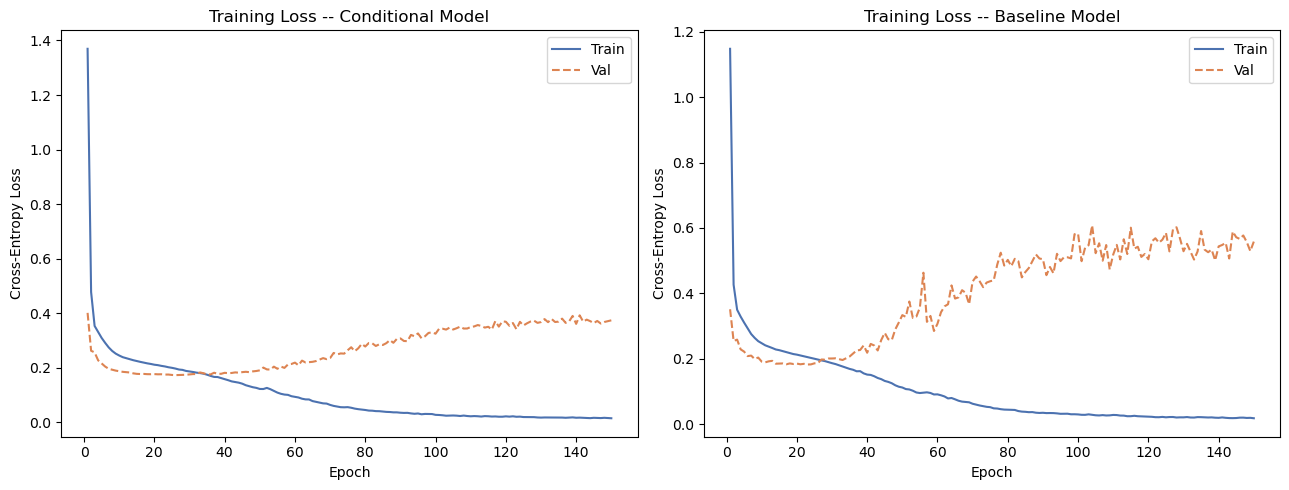

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs = range(1, N_EPOCHS + 1)

for ax, title, t_losses, v_losses in [
    (axes[0], "Conditional Model", cond_train_losses, cond_val_losses),
    (axes[1], "Baseline Model",    base_train_losses, base_val_losses),
]:
    ax.plot(epochs, t_losses, label="Train", color="#4C72B0", linewidth=1.5)
    ax.plot(epochs, v_losses, label="Val",   color="#DD8452", linewidth=1.5, linestyle="--")
    ax.set_title(f"Training Loss -- {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
import os

os.makedirs("../outputs/model_artifacts", exist_ok=True)
torch.save(conditional_model.state_dict(), "../outputs/model_artifacts/level_generator.pt")
torch.save(baseline_model.state_dict(),    "../outputs/model_artifacts/baseline_generator.pt")

print("Artifacts saved.")
print(f"  Conditional -- final train: {cond_train_losses[-1]:.4f}  val: {cond_val_losses[-1]:.4f}")
print(f"  Baseline    -- final train: {base_train_losses[-1]:.4f}  val: {base_val_losses[-1]:.4f}")

Artifacts saved.
  Conditional -- final train: 0.0148  val: 0.3738
  Baseline    -- final train: 0.0176  val: 0.5583


Both models trained quickly on the RTX 3080, completing 150 epochs in seconds due to the small corpus size.

Both models overfit substantially. Training loss for the conditional model dropped to 0.0148 by epoch 150, while validation loss climbed from a minimum of 0.1735 at epoch 25 to 0.3738 at the final epoch. The baseline model shows the same pattern with a more pronounced divergence, reaching a training loss of 0.0176 against a validation loss of 0.5583. This overfitting is expected given the small training set of 128 sequences and a model with 3.28 million parameters. The model has sufficient capacity to memorize the training data rather than learning generalizable structural patterns.

The conditional model generalizes better than the baseline throughout training. At epoch 50, the conditional validation loss (0.1905) is already substantially lower than the baseline (0.3333), and this gap widens through the remaining epochs. The lower validation loss of the conditional model suggests that the difficulty control token provides a useful structural signal that reduces uncertainty during prediction, even under overfitting conditions. This is the primary evidence that conditioning has a measurable effect.

For generation quality, the model checkpoint near epoch 25 to 50 represents the best balance between learning level structure and avoiding memorization. The saved artifacts at epoch 150 reflect the most trained state but may reproduce training sequences more closely than generating novel content. This tradeoff is examined in the Evaluation and Error Analysis sections.

## Sample Generation

We generate level segments from the conditional model at each difficulty setting and from the baseline unconditional model for comparison. Temperature is set to 1.0 for standard sampling.

In [31]:
def generate_level(
    model: nn.Module,
    difficulty: str,
    temperature: float = 1.0,
) -> dict:
    """Generate a level segment autoregressively from a trained conditional model.

    The difficulty control token is used as the generation prompt. At each step
    the model predicts the next tile token given all preceding tokens. Control
    tokens are masked from tile positions to prevent invalid output.

    Parameters
    ----------
    model : nn.Module
        Trained LevelTransformer.
    difficulty : str
        One of 'Easy', 'Medium', or 'Hard'.
    temperature : float
        Sampling temperature. Lower values produce more deterministic output.

    Returns
    -------
    dict
        Keys: 'difficulty' (str) and 'rows' (list of str).
    """
    model.eval()
    tokens = [CONTROL_TOKENS[difficulty]]
    control_ids = list(CONTROL_TOKENS.values())
    with torch.no_grad():
        for _ in range(SEQ_LEN - 1):
            x = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
            logits = model(x)[0, -1, :] / temperature
            logits[control_ids] = float('-inf')
            probs = torch.softmax(logits, dim=-1)
            tokens.append(torch.multinomial(probs, 1).item())
    return decode_sequence(tokens)


def generate_baseline_level(temperature: float = 1.0) -> dict:
    """Generate a level segment autoregressively from the baseline unconditional model.

    Seeded with a single empty-sky token since the baseline model has no
    control token. Output is not conditioned on any difficulty target.

    Parameters
    ----------
    temperature : float

    Returns
    -------
    dict
        Keys: 'difficulty' (always 'Baseline') and 'rows' (list of str).
    """
    baseline_model.eval()
    tokens = [0]  # seed with '-' (empty sky)
    with torch.no_grad():
        for _ in range(SEQ_LEN - 2):
            x = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
            logits = baseline_model(x)[0, -1, :] / temperature
            logits[list(CONTROL_TOKENS.values())] = float('-inf')
            probs = torch.softmax(logits, dim=-1)
            tokens.append(torch.multinomial(probs, 1).item())
    flat = [ID_TO_CHAR[t] for t in tokens]
    rows = [''.join(flat[i * 32:(i + 1) * 32]) for i in range(14)]
    return {'difficulty': 'Baseline', 'rows': rows}

In [32]:
print('=== Conditional Model Samples (temperature=1.0) ===')
for difficulty in ['Easy', 'Medium', 'Hard']:
    print(f'--- {difficulty} ---')
    for _ in range(2):
        sample = generate_level(conditional_model, difficulty, temperature=1.0)
        for row in sample['rows']:
            print(' ', row)
        print()

print('=== Baseline Model Samples ===')
for _ in range(3):
    sample = generate_baseline_level(temperature=1.0)
    for row in sample['rows']:
        print(' ', row)
    print()

=== Conditional Model Samples (temperature=1.0) ===
--- Easy ---
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  QQQ-----------SSSS--------SSSSS-
  --------------------------------
  --------------------------------
  --------------------E-----------
  QQQ----------S-----<>---QQQQ--QQ
  -------------------[]-----------
  -------------------[]-----------
  ----E-E--E--EE-E---[]-------E-EE
  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  --------------------------------
  ---------------SSSSS------------
  --------------------------------
  --------------------------------
  ----------------E-------------SS
  ---------------SSSSS------------
  ----------E-----------X----B----
  ---B-----<>-----------X----b----
  ---b-----[]-----------

The conditional model produces structurally coherent level segments across all three difficulty settings. The most visible difference between classes is in the ground row. Easy samples maintain a solid, unbroken ground row throughout, Medium samples introduce one or two ground gaps, and Hard samples show heavily fragmented ground rows with multiple gaps and floating platform sections that require more complex navigation.

One notable pattern in the Easy samples is a higher concentration of enemies and structural elements than might be intuitively expected for an easy level. This reflects how the difficulty score is weighted: ground gap length carries the dominant signal (weight 5 per tile of gap), while enemy density is a secondary factor (weight 40 on a fraction rarely above 0.02). A chunk can have many enemies and still score Easy as long as the ground remains intact. This is a known limitation of the heuristic scoring system and is discussed further in the Limitations section.

The baseline model samples lack the structural coherence seen in the conditional outputs. One baseline sample appears to reproduce a memorized training chunk (the stacked pipe structure visible in the third sample closely matches patterns from mario-1-1). Another baseline sample embeds a pipe top tile directly into the ground row, which is token valid but structurally unusual and would not appear in a human designed level. These observations support the conclusion that conditioning provides a meaningful organizational signal beyond what the unconditional model learns on its own.

## Evaluation

## Failure Cases and Error Analysis

## Limitations, Bias, and Responsible Use

## Final Notebook Summary